# Части 1-2: Детекция номерных знаков

**Часть 1** — псевдо-разметка датасета предобученным YOLOv5-детектором + ручная верификация.
**Часть 2** — обучение YOLOv8n на размеченных данных + метрики + анализ ошибок.

In [2]:
%matplotlib inline

import os
import sys
import shutil
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

RAW_DATASET   = Path(r"C:\ITMO\number_car_detect\number_car_detect")
SEMINAR_DIR   = Path(r"C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01")
YOLO_DATASET  = SEMINAR_DIR / "yolo_dataset"
LABELS_RAW    = YOLO_DATASET / "labels_raw"
IMAGES_RAW    = YOLO_DATASET / "images_raw"
WILD_TEST_DIR = SEMINAR_DIR / "wild_test"

for d in [YOLO_DATASET, LABELS_RAW, IMAGES_RAW, WILD_TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

exts = {".jpg", ".jpeg", ".png", ".bmp"}
all_images = sorted([p for p in RAW_DATASET.iterdir() if p.suffix.lower() in exts])
print(f"Dirs created. Raw images: {len(all_images)}")

Dirs created. Raw images: 368


## Часть 1.1–1.2: Псевдо-разметка предобученным детектором

Используем `keremberke/yolov5m-license-plate` (YOLOv5-формат) через `torch.hub`.
Результат сохраняем в YOLO-формат с нормированными координатами. Это вместо ручной разметки

In [3]:
import torch
from huggingface_hub import hf_hub_download

# Скачиваем веса YOLOv5 с HuggingFace
model_path = hf_hub_download(
    repo_id="keremberke/yolov5m-license-plate",
    filename="best.pt",
)
print("Downloaded weights:", model_path)

# YOLOv5 custom-веса загружаются через torch.hub, НЕ через ultralytics.YOLO()
pretrained = torch.hub.load(
    "ultralytics/yolov5",
    "custom",
    path=model_path,
    force_reload=True,
    verbose=False,
)
pretrained.eval()
pretrained.conf = 0.25   # порог уверенности
pretrained.iou  = 0.45   # NMS IoU
print("Model classes:", pretrained.names)

c:\ITMO\designing_neural_network_architectures_2025_02\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded weights: C:\Users\Admin\.cache\huggingface\hub\models--keremberke--yolov5m-license-plate\snapshots\2bc5d847462e40bbae9fa8a868c2a402e8491331\best.pt


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\Admin/.cache\torch\hub\master.zip
YOLOv5  2026-5-29 Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)

Fusing layers... 
Model summary: 212 layers, 20852934 parameters, 0 gradients, 47.9 GFLOPs
Adding AutoShape... 


Model classes: {0: 'license_plate'}


In [4]:
# Копируем все изображения в images_raw/ (удобно для LabelImg)
for src in all_images:
    dst = IMAGES_RAW / src.name
    if not dst.exists():
        shutil.copy2(src, dst)
print(f"Copied {len(all_images)} images to images_raw/")

Copied 368 images to images_raw/


In [5]:
# Генерируем псевдо-метки
# YOLOv5 results API: results.xyxy[0] → тензор [x0, y0, x1, y1, conf, cls]
annotated = 0
skipped   = 0

for img_path in all_images:
    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    with torch.no_grad():
        results = pretrained(str(img_path), size=640)

    dets = results.xyxy[0]  # (N, 6): x0 y0 x1 y1 conf cls
    txt_path = LABELS_RAW / (img_path.stem + ".txt")

    if len(dets) == 0:
        txt_path.write_text("", encoding="utf-8")
        skipped += 1
        continue

    lines = []
    for x0, y0, x1, y1, conf, cls in dets.tolist():
        x_c = (x0 + x1) / 2 / W
        y_c = (y0 + y1) / 2 / H
        bw  = (x1 - x0) / W
        bh  = (y1 - y0) / H
        lines.append(f"0 {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")

    txt_path.write_text("\n".join(lines), encoding="utf-8")
    annotated += 1

print(f"Annotated: {annotated},  no detection: {skipped}")

C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models

Annotated: 364,  no detection: 4


C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users\Admin/.cache\torch\hub\ultralytics_yolov5_master\models

## Часть 1.3–1.4: Train/val/test сплит и финальный датасет

In [6]:
for split in ["train", "val", "test"]:
    (YOLO_DATASET / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET / "labels" / split).mkdir(parents=True, exist_ok=True)

# Берём только изображения с непустой аннотацией
valid_images = [
    p for p in all_images
    if (LABELS_RAW / (p.stem + ".txt")).exists()
    and (LABELS_RAW / (p.stem + ".txt")).stat().st_size > 0
]
print(f"Images with detections: {len(valid_images)} / {len(all_images)}")

random.shuffle(valid_images)
n       = len(valid_images)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

splits = {
    "train": valid_images[:n_train],
    "val":   valid_images[n_train:n_train + n_val],
    "test":  valid_images[n_train + n_val:],
}

for split, imgs in splits.items():
    for img_path in imgs:
        lbl_src = LABELS_RAW / (img_path.stem + ".txt")
        shutil.copy2(img_path, YOLO_DATASET / "images" / split / img_path.name)
        shutil.copy2(lbl_src,  YOLO_DATASET / "labels" / split / lbl_src.name)
    print(f"  {split}: {len(imgs)} images")

Images with detections: 364 / 368
  train: 254 images
  val: 54 images
  test: 56 images


In [7]:
data_yaml_content = f"""path: {YOLO_DATASET.as_posix()}
train: images/train
val: images/val
test: images/test

nc: 1
names:
  - license_plate
"""
data_yaml_path = YOLO_DATASET / "data.yaml"
data_yaml_path.write_text(data_yaml_content, encoding="utf-8")
print(data_yaml_content)

path: C:/ITMO/designing_neural_network_architectures_2025_02/seminar_01/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 1
names:
  - license_plate



## Визуальная проверка разметки

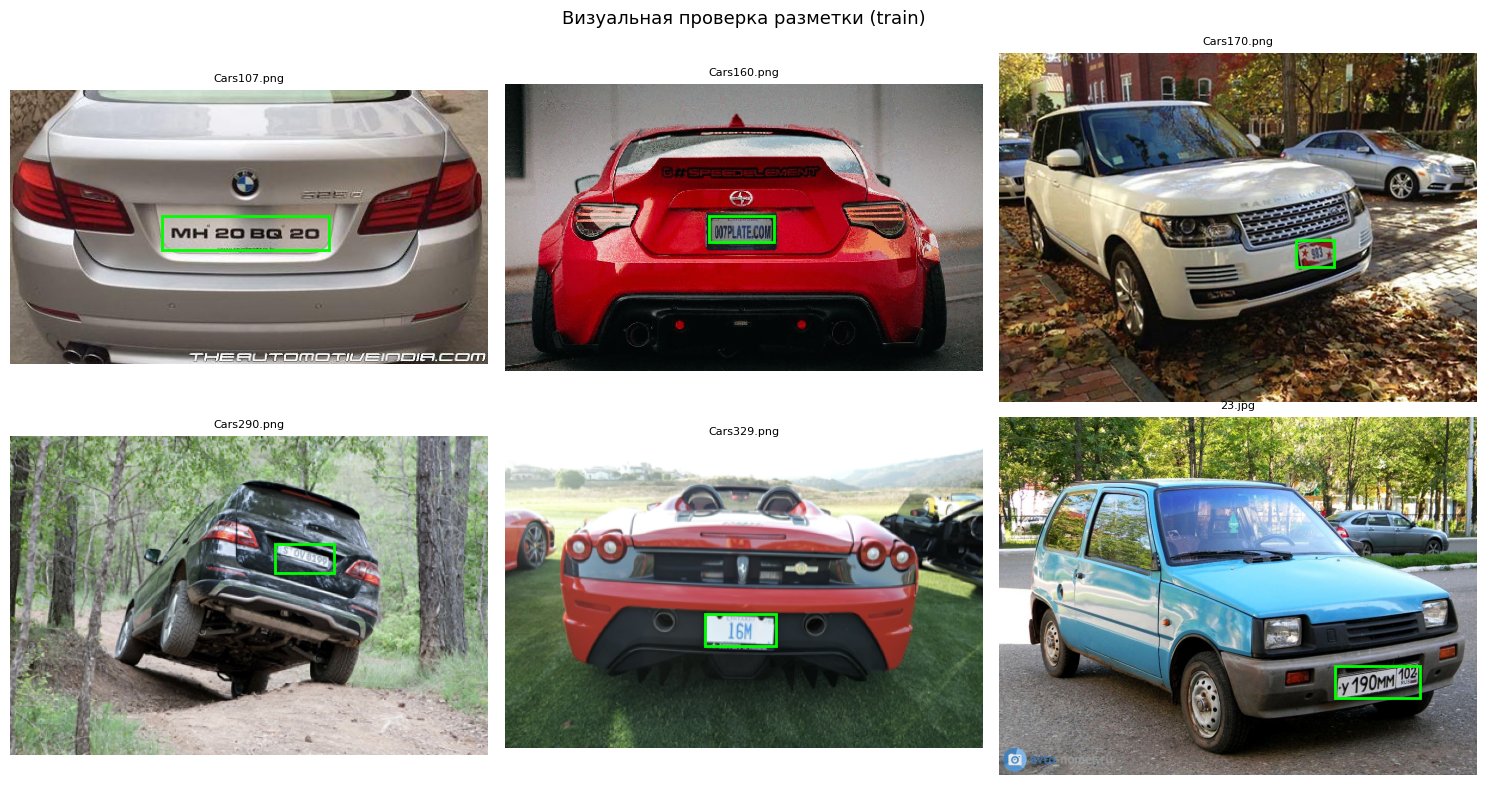

In [17]:
def draw_yolo_boxes(ax, img, label_path):
    W, H = img.size
    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            _, x_c, y_c, bw, bh = map(float, parts)
            x0 = (x_c - bw / 2) * W
            y0 = (y_c - bh / 2) * H
            ax.add_patch(patches.Rectangle(
                (x0, y0), bw * W, bh * H,
                linewidth=2, edgecolor="lime", facecolor="none"
            ))
    ax.axis("off")

train_imgs = list((YOLO_DATASET / "images" / "train").iterdir())
sample = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample):
    img = Image.open(img_path)
    lbl = YOLO_DATASET / "labels" / "train" / (img_path.stem + ".txt")
    draw_yolo_boxes(ax, img, lbl)
    ax.set_title(img_path.name, fontsize=8)
plt.suptitle("Визуальная проверка разметки (train)", fontsize=13)
plt.tight_layout()
plt.show()

## Часть 2.1: Обучение YOLOv8n

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data=str(data_yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    project=str(SEMINAR_DIR / "runs" / "detect"),
    name="train",
    seed=RANDOM_SEED,
    exist_ok=True,
)

best_weights = SEMINAR_DIR / "runs" / "detect" / "train" / "weights" / "best.pt"
print("Best weights:", best_weights)

Ultralytics 8.4.56  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fal

## Часть 2.2: Метрики на test

In [10]:
trained_model = YOLO(str(best_weights))
test_metrics  = trained_model.val(data=str(data_yaml_path), split="test", verbose=True)

print("\n=== Test Metrics ===")
print(f"mAP@0.5:       {test_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:  {test_metrics.box.map:.4f}")
print(f"Precision:     {test_metrics.box.mp:.4f}")
print(f"Recall:        {test_metrics.box.mr:.4f}")

Ultralytics 8.4.56  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1519.7405.7 MB/s, size: 371.8 KB)
val: Scanning C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01\yolo_dataset\labels\test... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 528.3it/s 0.1s0.0s
val: New cache created: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01\yolo_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5s/it 6.0s1.0s4s
                   all         56         70      0.924      0.871      0.918      0.662
Speed: 4.1ms preprocess, 13.8ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to C:\ITMO\designing_neural_network_architectures_2025_02\runs\detect\val

=== Test Metrics ===
mAP@0.5:   

## Анализ ошибок: сложные изображения

In [11]:
test_imgs      = list((YOLO_DATASET / "images" / "test").iterdir())
test_lbls_dir  = YOLO_DATASET / "labels" / "test"

per_image = []
for img_path in test_imgs:
    r = trained_model.predict(str(img_path), conf=0.1, verbose=False)[0]
    gt_path  = test_lbls_dir / (img_path.stem + ".txt")
    n_gt     = sum(1 for l in gt_path.read_text(encoding="utf-8").strip().splitlines() if l.strip())
    n_pred   = len(r.boxes) if r.boxes is not None else 0
    max_conf = float(r.boxes.conf.max()) if n_pred > 0 else 0.0
    per_image.append(dict(path=img_path, n_gt=n_gt, n_pred=n_pred, max_conf=max_conf,
                          miss=(n_gt > 0 and n_pred == 0),
                          fp=(n_gt == 0 and n_pred > 0)))

hard = sorted(per_image, key=lambda x: (not x["miss"], x["max_conf"]))
print(f"Test images: {len(test_imgs)}")
print(f"Missed (FN): {sum(1 for r in per_image if r['miss'])}")
print(f"False pos:   {sum(1 for r in per_image if r['fp'])}")

Test images: 56
Missed (FN): 1
False pos:   0


In [ ]:

n_show = min(5, len(hard))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

for ax, info in zip(axes, hard[:n_show]):
    r   = trained_model.predict(str(info["path"]), conf=0.1, verbose=False)[0]
    img = Image.open(info["path"])
    ax.imshow(img)
    if r.boxes is not None:
        for box in r.boxes:
            x0, y0, x1, y1 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            ax.add_patch(patches.Rectangle(
                (x0, y0), x1-x0, y1-y0,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x0, y0-5, f"{conf:.2f}", color="red", fontsize=8)
    status = "MISS" if info["miss"] else ("FP" if info["fp"] else "OK")
    ax.set_title(f"{info['path'].name}\nGT:{info['n_gt']} Pred:{info['n_pred']} [{status}]", fontsize=7)
    ax.axis("off")

plt.suptitle("Топ-5 сложных изображений (test)", fontsize=13)
plt.tight_layout()
plt.show()

### Краткий анализ сложных случаев

Типичные причины ошибок:
- **Малый размер номера** — занимает < 2% площади, ниже разрешения фич-карты YOLOv8n.
- **Частичное перекрытие** — номер обрезан кадром или скрыт объектом.
- **Плохое освещение / блик** — засветка или тень скрывают символы.
- **Сильный перспективный ракурс** — модель хуже справляется с искаженными фотками

## Тест на изображениях из интернета

Взял 4 картинки из интернета, как мне показалось нетривиальные

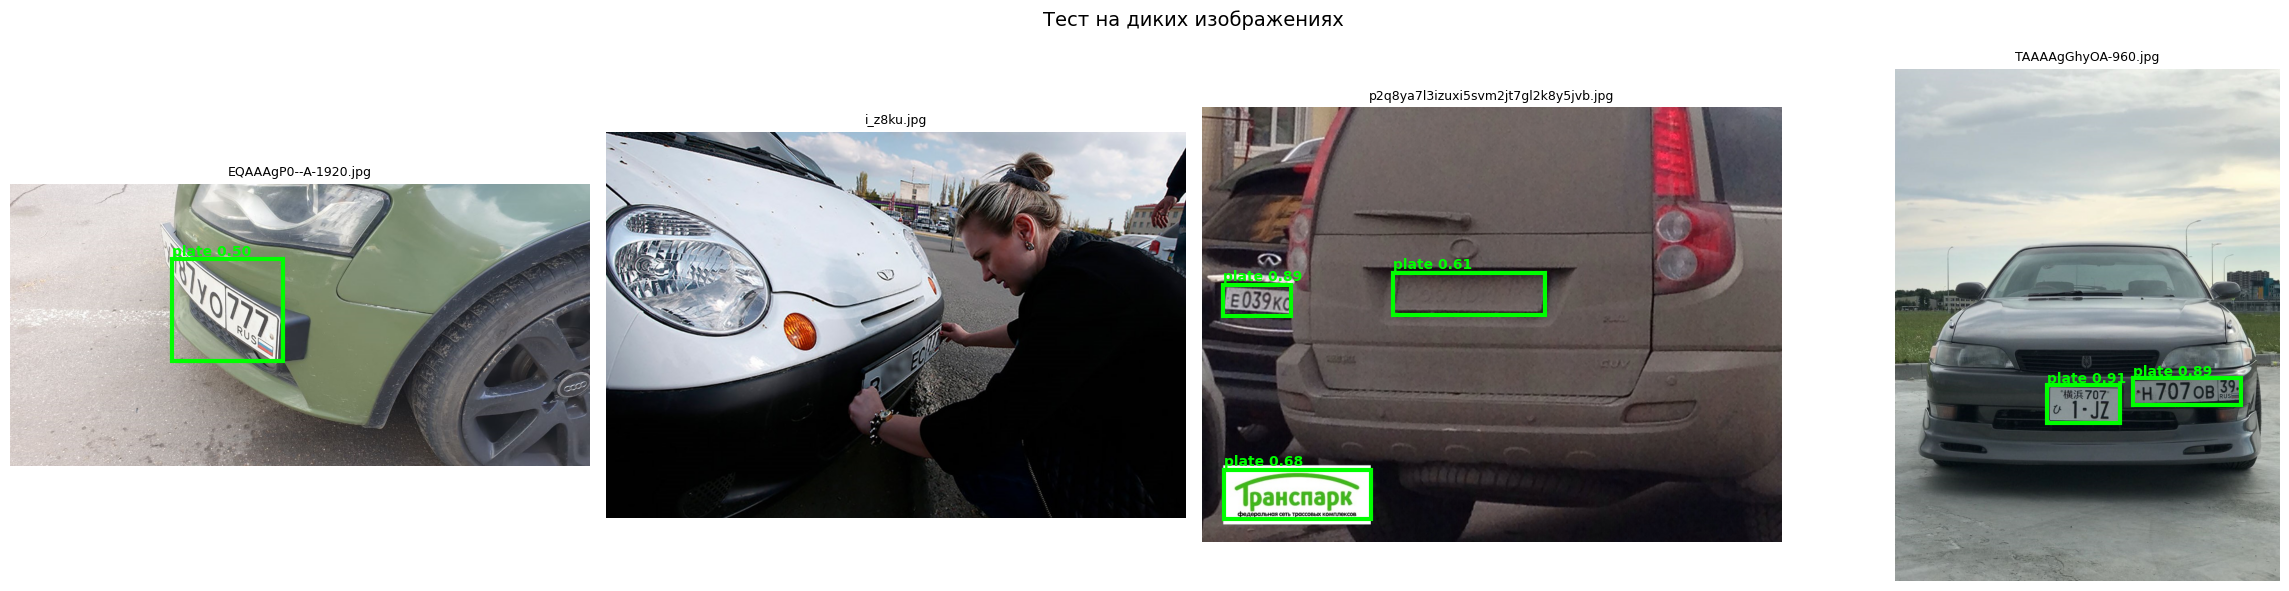

In [16]:
%matplotlib inline

wild_imgs = [p for p in WILD_TEST_DIR.glob("*.*") if p.suffix.lower() in exts]


fig, axes = plt.subplots(1, len(wild_imgs), figsize=(6 * len(wild_imgs), 6))
if len(wild_imgs) == 1:
    axes = [axes]
for ax, img_path in zip(axes, wild_imgs):
    r   = trained_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img = Image.open(img_path)
    ax.imshow(img)
    if r.boxes is not None:
        for box in r.boxes:
            x0, y0, x1, y1 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            ax.add_patch(patches.Rectangle(
                (x0, y0), x1-x0, y1-y0,
                linewidth=3, edgecolor="lime", facecolor="none"
            ))
            ax.text(x0, max(0, y0-8), f"plate {conf:.2f}",
                    color="lime", fontsize=10, fontweight="bold")
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
plt.suptitle("Тест на диких изображениях", fontsize=14)
plt.tight_layout()
plt.show()